In [ ]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from ctd_toolkit.plot.plot_fpca import PlotFPCA
%matplotlib qt

In [ ]:
inst = PlotFPCA(K = 50, var = ['PSAL_ADJUSTED', 'TEMP_ADJUSTED'],
                npc = 15,
                grid_path='C:/Users/m1_gui01/Desktop/PC_grid.nc',
                mfpca_path='C:/Users/m1_gui01/Desktop/mfpca.npz')

<unknown>:93: SyntaxWarning: invalid escape sequence '\%'
<unknown>:97: SyntaxWarning: invalid escape sequence '\%'
<unknown>:93: SyntaxWarning: invalid escape sequence '\%'
<unknown>:97: SyntaxWarning: invalid escape sequence '\%'


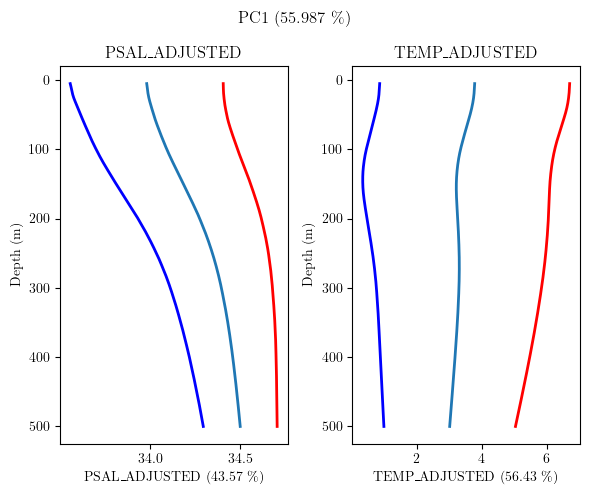

In [34]:
inst.basis_function_variation(npc = 0)

In [42]:
from matplotlib import pyplot as plt
plt.scatter(inst.mfpca['pc'][:,0], inst.mfpca['pc'][:,1], alpha = 0.2, c = inst.gps[:,0], s = 2)
len(inst.mfpca['pc'][:,0])

262040

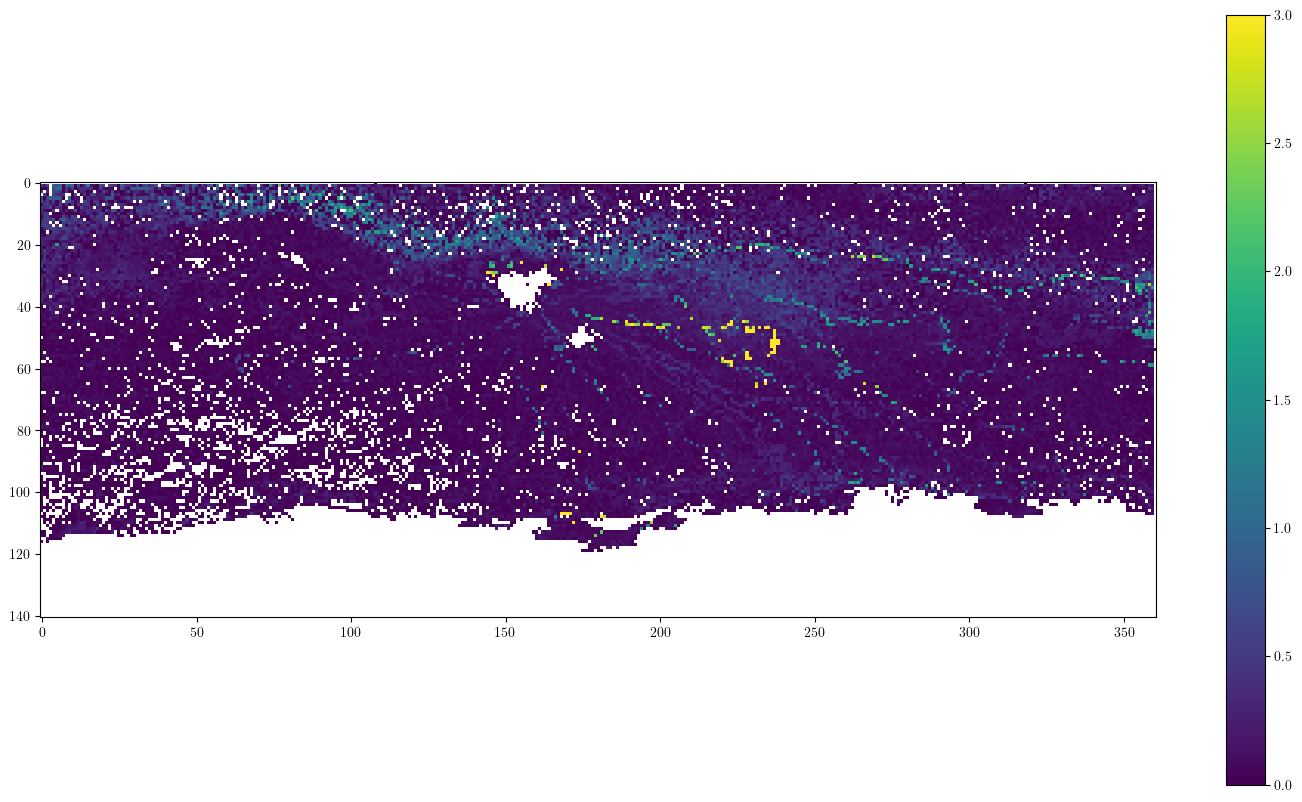

In [27]:
fig, ax = plt.subplots(figsize = (18,10))
im = ax.imshow(np.nanstd(inst.ds['PC'].values[:,:,:,0], axis = 0)[::-1], vmin = 0, vmax = 3)
fig.colorbar(im, ax = ax)


In [35]:
import rioxarray
inst.ds["PC"].isel(pc=1).mean("time").rio.set_spatial_dims(x_dim="longitude", y_dim="latitude").rio.write_crs("EPSG:4326").rio.to_raster("C:/Users/m1_gui01/Desktop/postdoc/oceano/QGIS/avg_pc1.tif")

C:\Users\m1_gui01\Desktop\CTD_Toolkit\src\ctd_toolkit\plot\plot_fpca.py:122: RuntimeWarning: Mean of empty slice
  _data = np.nanmean(_data['PC'][:][:,:,:,pc], axis = 0) #np.isin(self.month_data, self.months)


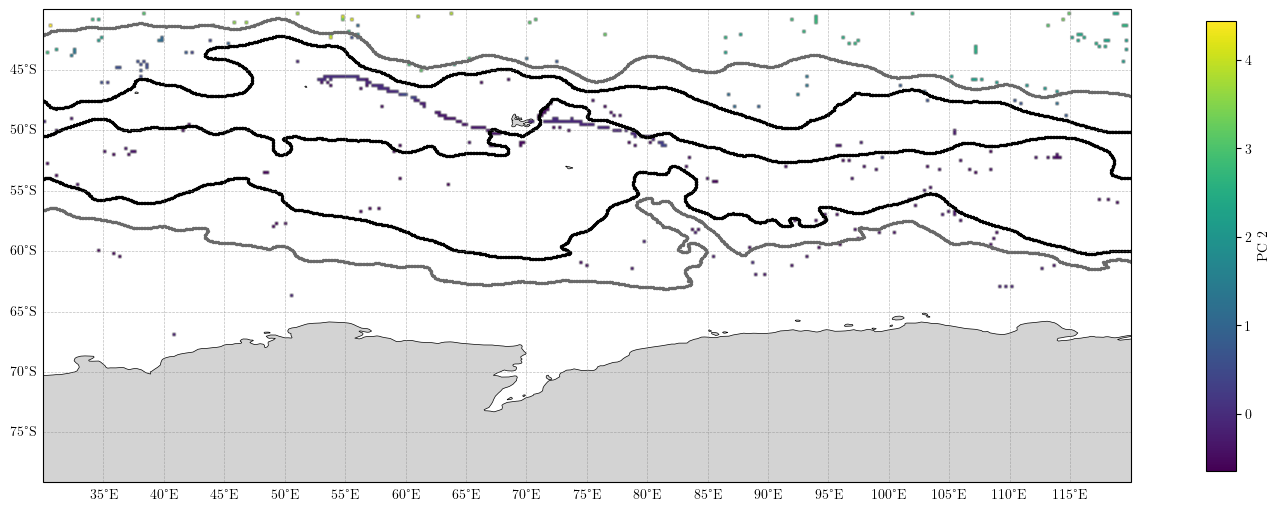

In [9]:
inst.define_boundaries(front_path = 'C:/Users/m1_gui01/Desktop/postdoc/oceano/fronts.nc', upper_front=None)
inst.months = None
inst.map_pc(time_range = (pd.Timestamp(2023,10,1), pd.Timestamp(2023,10,31)))

C:\Users\m1_gui01\Desktop\CTD_Toolkit\src\ctd_toolkit\plot\plot_fpca.py:122: RuntimeWarning: Mean of empty slice
  _data = np.nanmean(_data['PC'][:][:,:,:,pc], axis = 0) #np.isin(self.month_data, self.months)


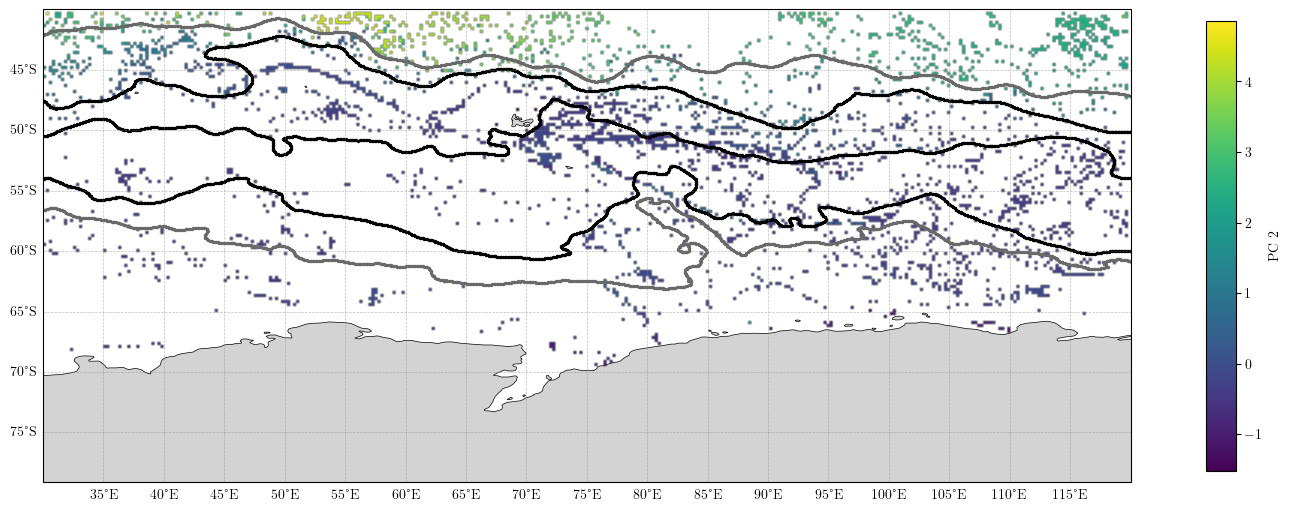

In [10]:
inst.map_pc(time_range = (pd.Timestamp(2024,1,1), pd.Timestamp(2024,12,31)))


In [43]:
inst.months = None
inst.latitude_gradient(pc = 1)

C:\Users\m1_gui01\Desktop\CTD_Toolkit\src\ctd_toolkit\plot\plot_fpca.py:142: RuntimeWarning: Mean of empty slice
  ax.scatter(np.nanmean(self.ds['PC'][:].data[time_mask, :, :, pc], axis=(0, 2)),
C:\Users\m1_gui01\Desktop\CTD_Toolkit\src\ctd_toolkit\plot\plot_fpca.py:142: RuntimeWarning: Mean of empty slice
  ax.scatter(np.nanmean(self.ds['PC'][:].data[time_mask, :, :, pc], axis=(0, 2)),
C:\Users\m1_gui01\Desktop\CTD_Toolkit\src\ctd_toolkit\plot\plot_fpca.py:142: RuntimeWarning: Mean of empty slice
  ax.scatter(np.nanmean(self.ds['PC'][:].data[time_mask, :, :, pc], axis=(0, 2)),
C:\Users\m1_gui01\Desktop\CTD_Toolkit\src\ctd_toolkit\plot\plot_fpca.py:142: RuntimeWarning: Mean of empty slice
  ax.scatter(np.nanmean(self.ds['PC'][:].data[time_mask, :, :, pc], axis=(0, 2)),
C:\Users\m1_gui01\Desktop\CTD_Toolkit\src\ctd_toolkit\plot\plot_fpca.py:142: RuntimeWarning: Mean of empty slice
  ax.scatter(np.nanmean(self.ds['PC'][:].data[time_mask, :, :, pc], axis=(0, 2)),
C:\Users\m1_gui01\Desktop

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
x = np.nanstd(inst.ds['PC'].values[:,:,:,0], axis = (1,2))
y = np.nanstd(inst.ds['PC'].values[:,:,:,1], axis = (1,2))
z = [pd.to_datetime(dt).timestamp() for dt in inst.ds['time'][:].data]

ax.scatter(x, y, z)
fig.show()

In [48]:
inst.mfpca.keys()

dict_keys(['fns', 'source', 'profile', 'alpha', 'values', 'vectors', 'vectnotWM', 'axe', 'pc', 'pval', 'alpha_mean', 'W', 'M', 'Wdem', 'Wdeminv', 'W_i', 'sigma2', 'na_mask'])

In [51]:
mapping = {s: i for i, s in enumerate(set(inst.mfpca['fns']))}
encoded = [mapping[s] for s in inst.mfpca['fns']]

plt.scatter(inst.mfpca['pc'][:,0], inst.mfpca['pc'][:, 1], c = encoded, s = 5, alpha = 0.5)

In [ ]:
from umap import UMAP
from sklearn.cluster import HDBSCAN

X = inst.mfpca['pc'][:, :10]   # not only first 2 PCs

X_umap = UMAP(n_neighbors=30, min_dist=0.0, n_components=2, random_state=0).fit_transform(X)
clusterer = HDBSCAN(min_cluster_size=200, min_samples=20, cluster_selection_epsilon=0.02)
labels = clusterer.fit_predict(X_umap)

C:\Users\m1_gui01\Desktop\CTD_Toolkit\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\m1_gui01\Desktop\CTD_Toolkit\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [58]:
plt.scatter(inst.mfpca['pc'][:,0], inst.mfpca['pc'][:, 1], c = labels, s = 5, alpha = 0.5)